In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
data=pd.read_csv("dataset.csv")
data

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [4]:
X=data[["danceability", "energy", "acousticness", "valence"]]
X

,danceability,energy,acousticness,valence
0,0.676,0.4610,0.0322,0.7150
1,0.420,0.1660,0.9240,0.2670
2,0.438,0.3590,0.2100,0.1200
3,0.266,0.0596,0.9050,0.1430
4,0.618,0.4430,0.4690,0.1670
...,...,...,...,...
113995,0.172,0.2350,0.6400,0.0339
113996,0.174,0.1170,0.9940,0.0350
113997,0.629,0.3290,0.8670,0.7430
113998,0.587,0.5060,0.3810,0.4130


In [5]:
kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)

In [7]:
clusters=kmeans.fit_predict(X)
data["Cluster"]=clusters

In [9]:
for i in range(3):
    print("\n" + "="*50)
    print("CLUSTER", i + 1)
    print("="*50)
    cluster_data = data[data["Cluster"] == i]
    print(cluster_data[["danceability","energy", "acousticness", "valence"]])
    print("\nTotal Records :",len(cluster_data))


CLUSTER 1
        danceability  energy  acousticness  valence
0              0.676   0.461      0.032200    0.715
5              0.688   0.481      0.289000    0.666
7              0.703   0.444      0.559000    0.712
8              0.625   0.414      0.294000    0.669
18             0.625   0.414      0.294000    0.669
...              ...     ...           ...      ...
113815         0.578   0.910      0.000661    0.691
113824         0.506   0.795      0.130000    0.639
113876         0.633   0.694      0.099800    0.594
113918         0.627   0.843      0.003400    0.744
113930         0.651   0.561      0.274000    0.469

[41809 rows x 4 columns]

Total Records : 41809

CLUSTER 2
        danceability  energy  acousticness  valence
2              0.438   0.359       0.21000    0.120
9              0.442   0.632       0.42600    0.196
10             0.627   0.363       0.27900    0.301
14             0.755   0.780       0.12400    0.387
15             0.489   0.561       0.20000   

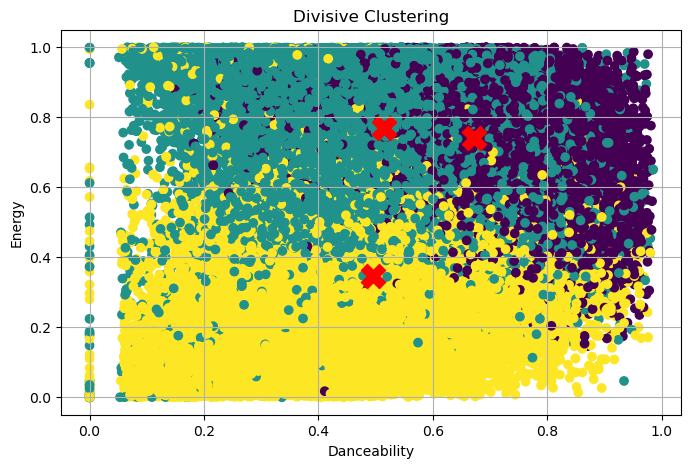

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(X["danceability"],X["energy"],c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, color="Red", marker="X")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.title("Divisive Clustering")
plt.grid(True)
plt.show()

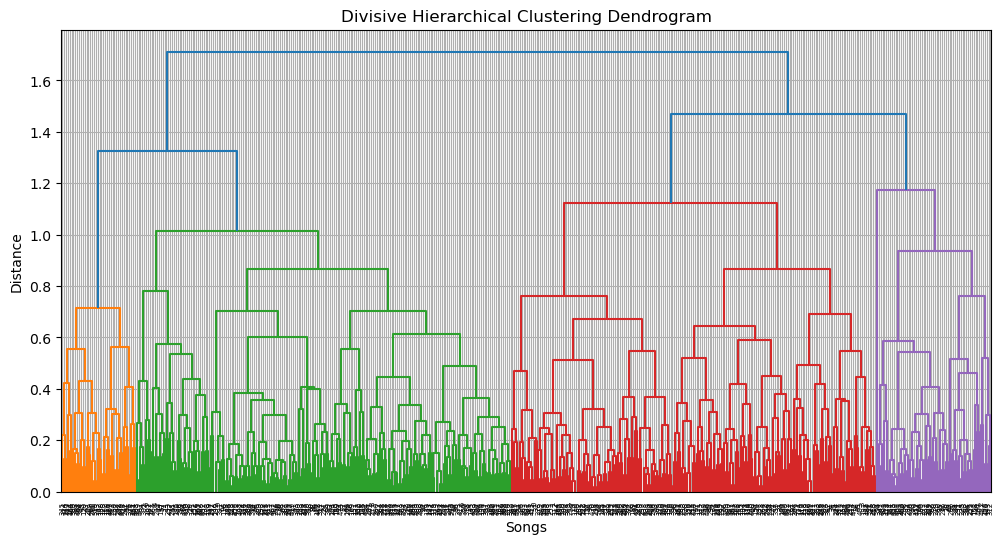

In [16]:
X_sample=X.sample(n=500, random_state=42)
Z = linkage(X_sample,method="complete")
plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Divisive Hierarchical Clustering Dendrogram")
plt.xlabel("Songs")
plt.ylabel("Distance")
plt.grid(True)
plt.show()